# FlowSOM — and what clustering does not replace

Automated clustering is a **complement** to gating, not a substitute. A gate is
auditable and reproducible and a reviewer can argue with it; a metacluster is
none of those things. The honest use is: find populations a strategy missed,
then go and draw the gate.

This notebook shows FlowSOM working, and then shows it failing in the specific
way it fails when you skip the gating — which is the part most tutorials leave
out.

Continues from [Gating-ML](t_flow_03_gatingml.ipynb).

In [1]:
# No data of your own is needed. ov.datasets.flow_demo_fcs() writes a SIMULATED
# FCS 3.1 file into the current working directory: 59,600 events, nine known
# populations, a real $SPILLOVER keyword, and a detector noise floor that pushes
# dim events below zero — which is why a log display axis will not do.
import numpy as np, pathlib
import omicverse as ov

ov.style()          # omicverse's plotting defaults — call this once, up front

path = ov.datasets.flow_demo_fcs()
print(path)


/Users/fernandozeng/miniforge3/envs/omictest/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.4   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

flow_demo.fcs


In [2]:
import omicverse as ov
import matplotlib.pyplot as plt
import numpy as np

adata = ov.datasets.flow_demo()      # = read_fcs(flow_demo_fcs()) + obs['population']
ov.flow.compensate(adata)

lin = ov.flow.Linear(t=262144.0)
lg  = ov.flow.Logicle(t=262144.0, m=4.5, w=1.0, a=0.0)
adata


AnnData object with n_obs × n_vars = 59600 × 8
    obs: 'sample', 'population'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnG', 'PnR'
    uns: 'meta', 'fcs', 'flow_demo', 'flow'
    layers: 'uncompensated'

In [3]:
def at(v):
    """A data value expressed on the logicle scale — how a threshold is really
    written. Typing 0.42 instead of at(600) is how gates drift."""
    return float(lg.apply(np.array([float(v)]))[0])

cells = ov.flow.PolygonGate(
    name="Cells", dims=("FSC-A", "SSC-A"),
    transforms={"FSC-A": lin, "SSC-A": lin},
    vertices=np.array([[0.12,0.01],[0.12,0.17],[0.40,0.32],
                       [0.68,0.32],[0.68,0.09],[0.38,0.01]]))
singlets = ov.flow.PolygonGate(
    name="Singlets", dims=("FSC-A", "FSC-H"),
    transforms={"FSC-A": lin, "FSC-H": lin},
    vertices=np.array([[0.05,0.03],[0.05,0.10],[0.75,0.86],[0.75,0.69]]))
live = ov.flow.RectangleGate(
    name="Live", dims=("Viability",), transforms={"Viability": lg},
    bounds=((None, at(1200)),))
cd3 = ov.flow.RectangleGate(
    name="CD3+", dims=("CD3",), transforms={"CD3": lg},
    bounds=((at(600), None),))
quad = ov.flow.QuadrantGate(
    name="CD4/CD8", dims=("CD4", "CD8"), transforms={"CD4": lg, "CD8": lg},
    dividers=(at(600), at(600)),
    quadrant_names=("DN", "CD4+CD8-", "CD4-CD8+", "DP"))

gs = ov.flow.GatingStrategy("T cell panel")
gs.add_gate(cells)
gs.add_gate(singlets, parent="Cells")
gs.add_gate(live,     parent="Singlets")
gs.add_gate(cd3,      parent="Live")
gs.add_gate(quad,     parent="CD3+")
print(gs.tree())


root
  └ Cells
    └ Singlets
      └ Live
        └ CD3+
          └ CD4/CD8
          └ DN
          └ CD4+CD8-
          └ CD4-CD8+
          └ DP


## Cluster on transformed values, not raw

The SOM follows whichever channel has the largest numbers. Raw fluorescence is
dominated by the brightest decade of the brightest fluorochrome, and the
"populations" that come out are then a description of the panel rather than of
the biology. Cluster on the *display* scale.

In [4]:
adata.layers["logicle"] = np.column_stack(
    [lin.apply(adata.X[:, i]) for i in range(3)]           # scatter: linear
    + [lg.apply(adata.X[:, i]) for i in range(3, adata.n_vars)]  # fluorescence
)
print(adata.layers["logicle"].min(), adata.layers["logicle"].max())

0.0176458191126585 0.8424009873865204


## FlowSOM on ungated events

Deliberately the wrong thing first. Note `markers=` — leaving FSC/SSC in lets
scatter dominate the map, and the clusters become shapes rather than
phenotypes.

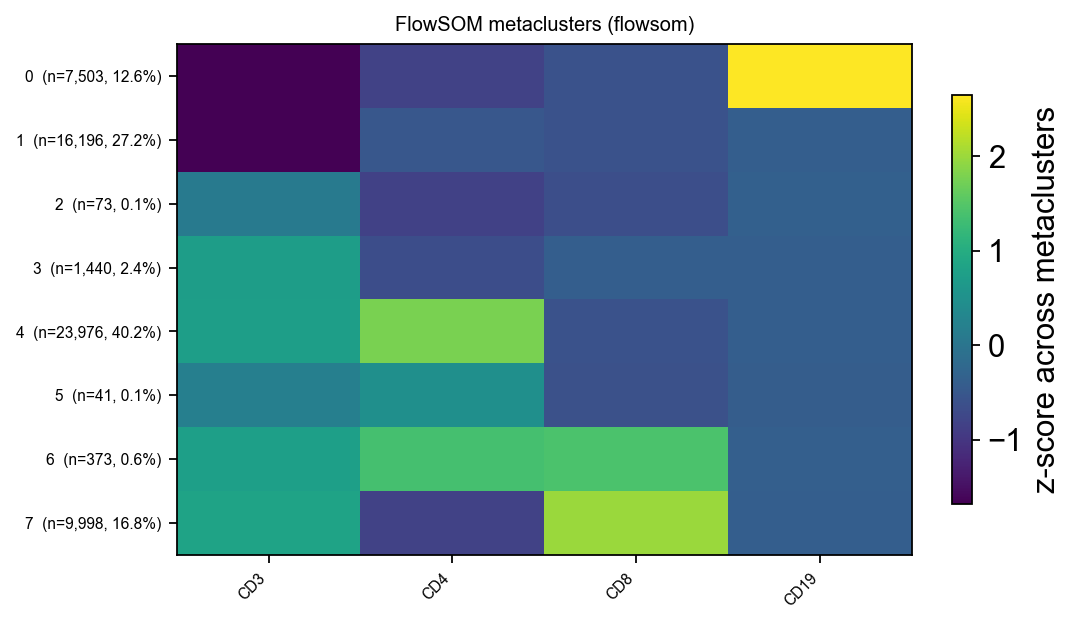

In [5]:
ov.flow.flowsom(adata, n_clusters=8, grid=(8, 8), n_epochs=12,
                layer="logicle", markers=["CD3", "CD4", "CD8", "CD19"],
                random_state=0)
ov.flow.flowsom_heatmap(adata, layer="logicle", figsize=(6.4, 4.2))
None

Readable enough: one CD19-high cluster, one CD8-high, one CD4-high,
and a large everything-low cluster. Now check it against the truth — which is
available here only because the sample is synthetic, and is exactly what you
never have on real data:

In [6]:
import pandas as pd

ct = pd.crosstab(adata.obs["flowsom"], adata.obs["population"])
ct

population     B  CD4 T  CD8 T  DN T  DP T  dead  debris  doublet  mono
flowsom                                                                
0           7500      0      0     0     0     0       3        0     0
1              0      0      0     0     0     0   10996        0  5200
2              0      0      0    72     0     0       1        0     0
3              0      0      2  1314   124     0       0        0     0
4              0  16998      0     0     4  3174       0     3800     0
5              0      2      0    14     0    25       0        0     0
6              0      0      0     0   372     1       0        0     0
7              0      0   9998     0     0     0       0        0     0

There is the failure. Look at the cluster containing the CD4 T cells:
it has swallowed the **dead cells and the doublets** as well. Both are CD3+CD4+
by fluorescence — a dead cell still has its surface markers, and a doublet is
two cells' worth of them — so on a marker panel alone they are indistinguishable
from the real population.

No amount of clustering fixes this. The information that separates them is in
the *scatter* channels and the viability dye, and it is the gating strategy that
uses it.

In [7]:
res = gs.apply(adata)
contaminating = adata.obs["population"].isin(["dead", "doublet"]).to_numpy()
target = ct["CD4 T"].idxmax()

print(f"cluster {target} (the CD4 T cluster):")
sel = (adata.obs["flowsom"] == target).to_numpy()
print(f"  events                 : {sel.sum():,}")
print(f"  dead or doublet        : {int((sel & contaminating).sum()):,} "
      f"({(sel & contaminating).sum() / sel.sum():.1%})")
print(f"  surviving the strategy : {int((sel & res.masks['Live'] & res.masks['Singlets']).sum()):,}")

cluster 4 (the CD4 T cluster):
  events                 : 23,976
  dead or doublet        : 6,974 (29.1%)
  surviving the strategy : 17,000


## FlowSOM after gating

The same algorithm, on the events the strategy kept. This is the order that
works.

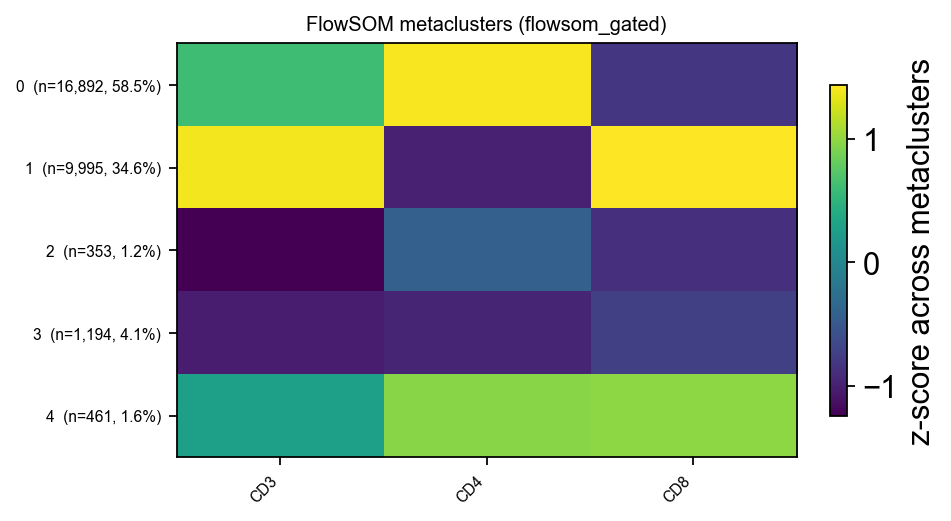

In [8]:
gated = adata[res.masks["CD3+"]].copy()
ov.flow.flowsom(gated, n_clusters=5, grid=(8, 8), n_epochs=12,
                layer="logicle", markers=["CD3", "CD4", "CD8"],
                random_state=0, key_added="flowsom_gated")
ov.flow.flowsom_heatmap(gated, key="flowsom_gated", layer="logicle",
                        markers=["CD3", "CD4", "CD8"], figsize=(5.4, 3.4))
None

In [9]:
pd.crosstab(gated.obs["flowsom_gated"], gated.obs["population"])

population     B  CD4 T  CD8 T  DN T  DP T
flowsom_gated                             
0              0  16891      0     0     1
1              0      0   9995     0     0
2              0    107      0   246     0
3              1      0      2  1153    38
4              0      0      0     0   461

Now the clusters are T-cell subsets rather than a mixture of
subsets and artefacts. The rare compartments do better, but read the table
honestly rather than taking the improvement on faith:

In [10]:
ct_g = pd.crosstab(gated.obs["flowsom_gated"], gated.obs["population"])
for pop in ["CD4 T", "CD8 T", "DN T", "DP T"]:
    col = ct_g[pop]
    print(f"{pop:6s} {col.sum():6,} events — "
          f"{col.max() / col.sum():5.1%} in its largest cluster "
          f"(cluster {col.idxmax()}), spread over {int((col > 0).sum())}")

CD4 T  16,998 events — 99.4% in its largest cluster (cluster 0), spread over 2
CD8 T   9,997 events — 100.0% in its largest cluster (cluster 1), spread over 2
DN T    1,399 events — 82.4% in its largest cluster (cluster 3), spread over 2
DP T      500 events — 92.2% in its largest cluster (cluster 4), spread over 3


CD4 and CD8 land almost entirely in one cluster each. DP does well
too. **DN does not** — it splits across two clusters, and that is worth saying
out loud rather than glossing: 1,400 events with no positive marker in the panel
are defined by what they *lack*, and a SOM has little to grip. The quadrant gate
finds them by construction; the clustering only mostly does.

## Where a cluster earns its place

Back-gating is what turns a metacluster into a claim you can defend: show where
its events sit on the axes a human would have gated.

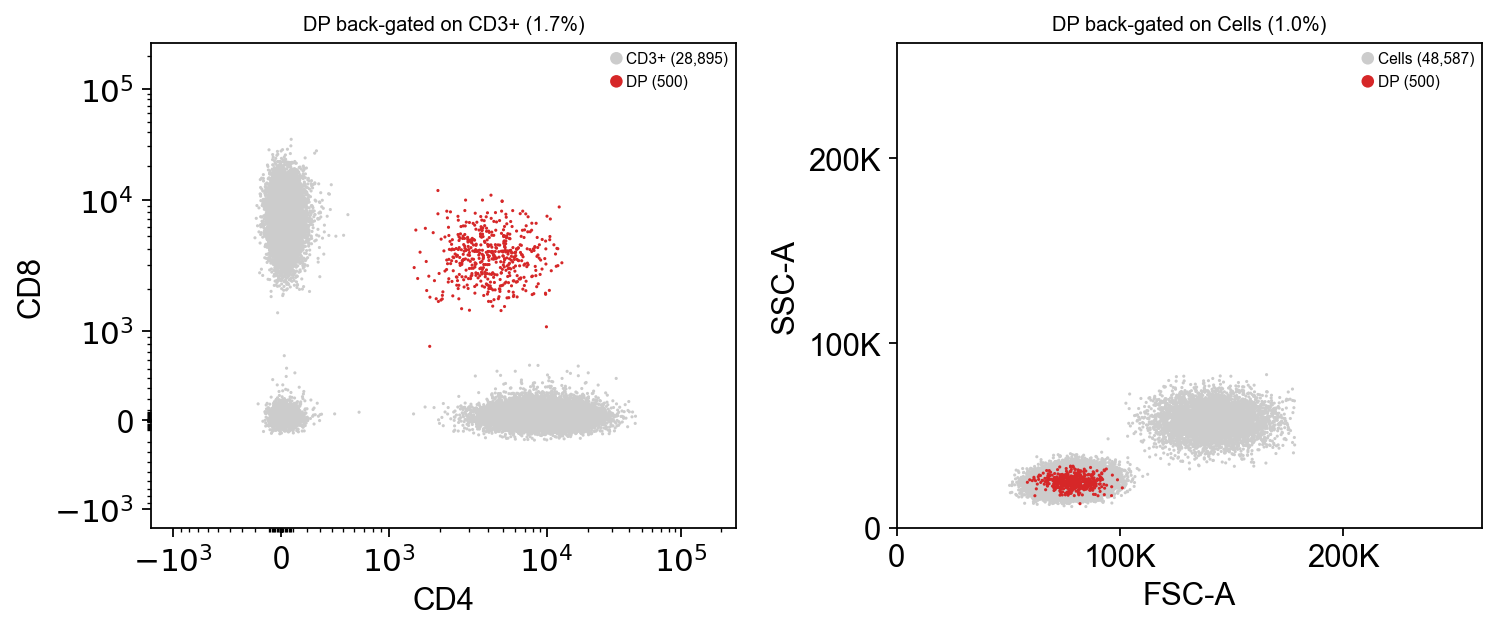

In [11]:
res_g = gs.apply(adata)
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
ov.flow.backgate(adata, "CD4", "CD8", result=res_g, population="DP",
                 parent="CD3+", transforms={"CD4": lg, "CD8": lg}, ax=axes[0])
ov.flow.backgate(adata, "FSC-A", "SSC-A", result=res_g, population="DP",
                 parent="Cells", transforms={"FSC-A": lin, "SSC-A": lin},
                 ax=axes[1])
plt.tight_layout()

## Summary of the series

| Notebook | What it covers |
|---|---|
| [01](t_flow_01_reading_and_compensation.ipynb) | `ov.io.read_fcs`, compensation, logicle / hyperlog / asinh |
| [02](t_flow_02_gating.ipynb) | gate geometry, the strategy tree, `stats()`, back-gating |
| [03](t_flow_03_gatingml.ipynb) | Gating-ML 2.0 round-trip, one strategy over a batch, diffing |
| 04 | FlowSOM, and the order that makes it trustworthy |

The rule the whole module is built around: **the gate carries the scale it was
drawn on.** Everything else — saving, sharing, re-applying, plotting — follows
from that.